# Fetch stamps and detections from ALeRCE for a given DiaObjectId 

Uses the **ALeRCE Python client** multisurvey stamps API to fetch science, template, and difference
stamps for a given LSST diaObject and saves them as FITS files in the data directory.

Reference: https://alerce.readthedocs.io/en/latest/tutorials/multisurvey_stamps_api.html

Based on patterns from: https://github.com/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from astropy.wcs import WCS

from alerce.core import Alerce

## 2. Connect to the ALeRCE client

In [2]:
# Default constructor works for both ZTF and LSST multisurvey queries
alerce_client = Alerce()
print("ALeRCE client ready.")

ALeRCE client ready.


## 3. Target object

`OUT_DIR` is the root data directory. Each diaObject gets its own subdirectory `OID_DIR = OUT_DIR / str(OID)`.

In [3]:
OID     = 313853517426065465    # LSST diaObjectId (integer)
OUT_DIR = Path("../../data")    # root output directory
OID_DIR = OUT_DIR / str(OID)    # per-object subdirectory
OID_DIR.mkdir(parents=True, exist_ok=True)

print(f"OID     : {OID}")
print(f"OUT_DIR : {OUT_DIR.resolve()}")
print(f"OID_DIR : {OID_DIR.resolve()}")

OID     : 313853517426065465
OUT_DIR : /home/jupyter/workspace/data
OID_DIR : /home/jupyter/workspace/data/313853517426065465


## 4. Query detections

In [4]:
df_dets = alerce_client.query_detections(OID, survey="lsst", format="pandas")

print(f"Total detections : {len(df_dets)}")
df_dets.head(3)

Total detections : 1131


,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,2,61088.211979,lsst,150.490734,2.775450,313853517426065465,170019716326752312,0,313853517426065465,5346.0600,...,False,False,False,False,False,False,False,False,False,r
1,2,61088.212444,lsst,150.490754,2.775457,313853517426065465,170019716459921433,0,313853517426065465,5698.3936,...,False,False,False,False,False,False,False,False,False,r
2,4,61088.214331,lsst,150.490731,2.775457,313853517426065465,170019716594663425,0,313853517426065465,6154.0117,...,False,False,False,False,False,False,False,False,False,z


## 5. Save detections to file

Saved as parquet rather than CSV — with 102 columns and mixed boolean/float/integer types,
parquet preserves dtypes cleanly and compresses much better than CSV.

In [5]:
det_path = OID_DIR / f"{OID}_detections.parquet"
df_dets.to_parquet(det_path, index=False)

print(f"Detections saved : {det_path}")
print(f"Rows x columns   : {df_dets.shape[0]} x {df_dets.shape[1]}")
print(f"File size        : {det_path.stat().st_size / 1024:.1f} kB")

Detections saved : ../../data/313853517426065465/313853517426065465_detections.parquet
Rows x columns   : 1131 x 102
File size        : 426.3 kB


In [6]:
# Only detections that triggered an alert carry stamps
df_stamped = df_dets[df_dets["has_stamp"] == True].sort_values("mjd").copy()

print(f"Detections with stamps : {len(df_stamped)}")
df_stamped[["measurement_id", "band_name", "mjd", "psfFlux", "psfFluxErr"]].head()

Detections with stamps : 1010


,measurement_id,band_name,mjd,psfFlux,psfFluxErr
991,313853517426065465,i,61024.245933,3715.8723,371.60650
992,313853517559234619,i,61024.246431,3474.9246,362.94952
993,313853517693976593,i,61024.246932,3340.8037,360.51367
994,313853517965033565,i,61024.247937,4367.2935,376.61790
995,313853532999516243,i,61024.320330,3837.1200,320.76390


## 7. Fetch stamps via `get_stamps()`

`alerce_client.get_stamps(survey, oid, candid, include_variance_and_mask=True)` returns a dict
with three keys:

| Key | Contents |
|---|---|
| `cutoutScience` | List of HDUs: `[flux, variance, mask]` |
| `cutoutTemplate` | List of HDUs: `[flux, variance, mask]` |
| `cutoutDifference` | List of HDUs: `[flux, variance, mask]` |

Each HDU has `.data` (numpy float32 array, nJy for flux) and `.header` (with full WCS).
When only the flux plane is returned (older API), the value is a single HDU rather than a list.

Here we fetch stamps for the **first three alert-bearing detections**.

In [7]:
STAMP_TYPES = ["Science", "Template", "Difference"]   # capitalised to match client keys
PLANES      = ["flux", "variance", "mask"]            # order returned by the API
N_FETCH     = 3                                       # change to len(df_stamped) for all

# list of dicts keyed by "{Stype}_{plane}", e.g. "Science_flux", "Template_variance", ...
stamp_rows = []

for _, row in df_stamped.head(N_FETCH).iterrows():
    mid = int(row["measurement_id"])
    print(f"Fetching measurement_id={mid}  band={row['band_name']}  mjd={row['mjd']:.4f} ...", end=" ")
    try:
        stamps = alerce_client.get_stamps(
            survey="lsst",
            oid=OID,
            candid=mid,                        # parameter is named 'candid' even for LSST
            include_variance_and_mask=True,    # request all three planes
        )
        entry = {
            "measurement_id": mid,
            "band":           row["band_name"],
            "mjd":            row["mjd"],
        }
        for stype in STAMP_TYPES:
            raw = stamps.get(f"cutout{stype}")
            if isinstance(raw, list):
                # Full response: [flux_hdu, variance_hdu, mask_hdu]
                for plane, hdu in zip(PLANES, raw):
                    entry[f"{stype}_{plane}"] = hdu
            elif raw is not None:
                # Fallback: single HDU (flux only)
                entry[f"{stype}_flux"] = raw
        stamp_rows.append(entry)
        print("ok")
    except Exception as exc:
        print(f"FAILED — {exc}")

print(f"\nSuccessfully fetched stamps for {len(stamp_rows)}/{N_FETCH} detections.")

Fetching measurement_id=313853517426065465  band=i  mjd=61024.2459 ... ok
Fetching measurement_id=313853517559234619  band=i  mjd=61024.2464 ... ok
Fetching measurement_id=313853517693976593  band=i  mjd=61024.2469 ... ok

Successfully fetched stamps for 3/3 detections.


## 8. Save as multi-extension FITS files

One file per cutout type per detection — three files per detection, mirroring the original alert packet layout:

```
{OID_DIR}/{OID}_{measurement_id}_science.fits    → [PRIMARY=flux, VARIANCE, MASK]
{OID_DIR}/{OID}_{measurement_id}_template.fits   → [PRIMARY=flux, VARIANCE, MASK]
{OID_DIR}/{OID}_{measurement_id}_difference.fits → [PRIMARY=flux, VARIANCE, MASK]
```

In [8]:
saved_files = []   # list of (measurement_id, stype, Path)

PLANE_EXTNAME = {"flux": None, "variance": "VARIANCE", "mask": "MASK"}
# flux → PRIMARY (None means PrimaryHDU); variance and mask → named ImageHDUs

for entry in stamp_rows:
    mid = entry["measurement_id"]
    print(f"\nmeasurement_id={mid}  band={entry['band']}  mjd={entry['mjd']:.4f}")

    for stype in STAMP_TYPES:
        hdus = []
        for plane in PLANES:
            hdu = entry.get(f"{stype}_{plane}")
            if hdu is None:
                continue
            extname = PLANE_EXTNAME[plane]
            if extname is None:
                hdus.append(fits.PrimaryHDU(data=hdu.data, header=hdu.header))
            else:
                hdus.append(fits.ImageHDU(data=hdu.data, header=hdu.header, name=extname))

        if not hdus:
            print(f"  x  {stype:12s} — no planes available")
            continue

        fname = OID_DIR / f"{OID}_{mid}_{stype.lower()}.fits"
        fits.HDUList(hdus).writeto(fname, overwrite=True)
        saved_files.append((mid, stype, fname))

        ext_names = [h.name if h.name else "PRIMARY" for h in hdus]
        size_kb   = fname.stat().st_size / 1024
        print(f"  ok {stype:12s} -> {fname.name}  {ext_names}  ({size_kb:.1f} kB)")

print(f"\nTotal FITS files written: {len(saved_files)}")


measurement_id=313853517426065465  band=i  mjd=61024.2459
  ok Science      -> 313853517426065465_313853517426065465_science.fits  ['PRIMARY', 'VARIANCE', 'MASK']  (33.8 kB)
  ok Template     -> 313853517426065465_313853517426065465_template.fits  ['PRIMARY', 'VARIANCE', 'MASK']  (36.6 kB)
  ok Difference   -> 313853517426065465_313853517426065465_difference.fits  ['PRIMARY', 'VARIANCE', 'MASK']  (33.8 kB)

measurement_id=313853517559234619  band=i  mjd=61024.2464
  ok Science      -> 313853517426065465_313853517559234619_science.fits  ['PRIMARY', 'VARIANCE', 'MASK']  (33.8 kB)
  ok Template     -> 313853517426065465_313853517559234619_template.fits  ['PRIMARY', 'VARIANCE', 'MASK']  (33.8 kB)
  ok Difference   -> 313853517426065465_313853517559234619_difference.fits  ['PRIMARY', 'VARIANCE', 'MASK']  (33.8 kB)

measurement_id=313853517693976593  band=i  mjd=61024.2469
  ok Science      -> 313853517426065465_313853517693976593_science.fits  ['PRIMARY', 'VARIANCE', 'MASK']  (33.8 kB)
  o

## 9. Inspect FITS headers

The stamps include full WCS — `CRVAL1/2` give the sky position of the reference pixel
and `BUNIT = 'nJy'` confirms the flux units.

In [9]:
# Show the extension structure and key header keywords of the first Science stamp
first_science = next((f for mid, st, f in saved_files if st == "Science"), None)

if first_science:
    with fits.open(first_science) as hdul:
        hdul.info()
        print()
        for ext in hdul:
            shape = ext.data.shape if ext.data is not None else None
            print("=" * 52)
            print(f"  Extension : {ext.name}   shape={shape}")
            print("=" * 52)
            print(repr(ext.header[:15]))
            print()
else:
    print("No Science stamp saved.")

Filename: ../../data/313853517426065465/313853517426065465_313853517426065465_science.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (30, 30)   float32   
  1  VARIANCE      1 ImageHDU         9   (30, 30)   float32   
  2  MASK          1 ImageHDU         8   (41, 41)   float64   

  Extension : PRIMARY   shape=(30, 30)
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   30                                                  
NAXIS2  =                   30                                                  
EXTEND  =                    T                                                  
CUTMINX =                 2982                                                  
CUTMINY =                 2357                  

## 10. Display stamps for each fetched detection

One figure per detection — rows are planes (flux / variance), columns are cutout types
(Science / Template / Difference). Flux uses ZScale; difference flux uses a symmetric stretch;
variance uses linear min–max.

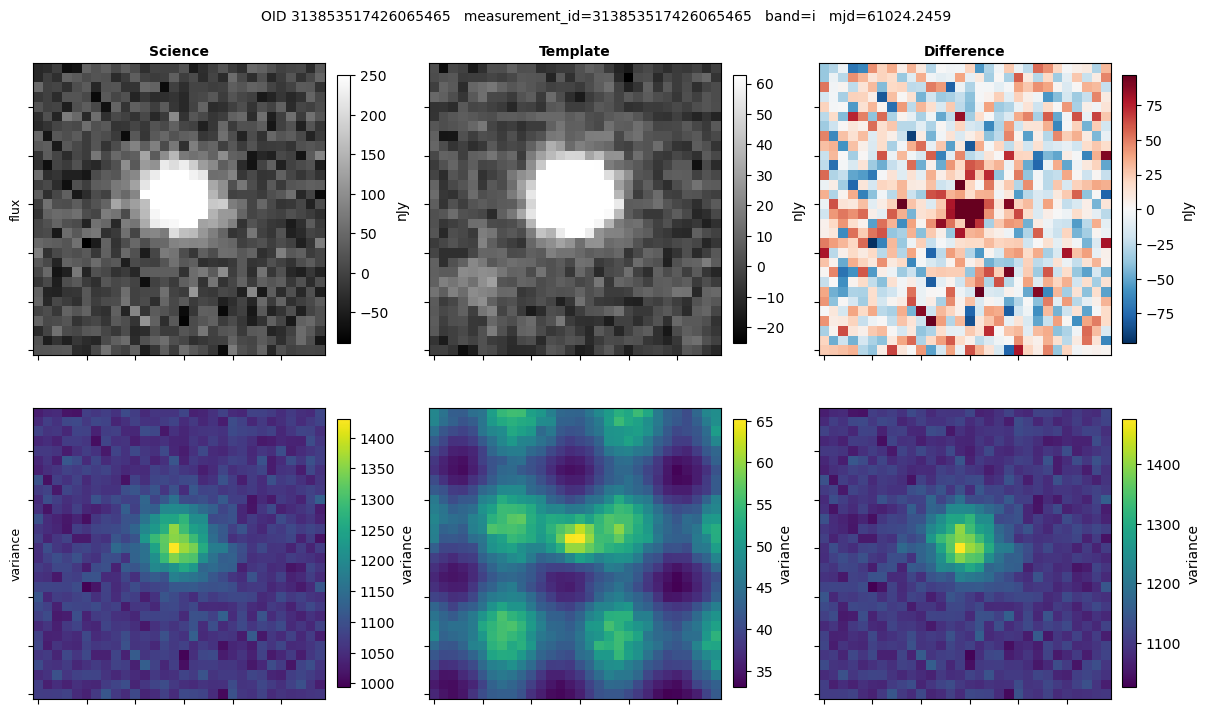

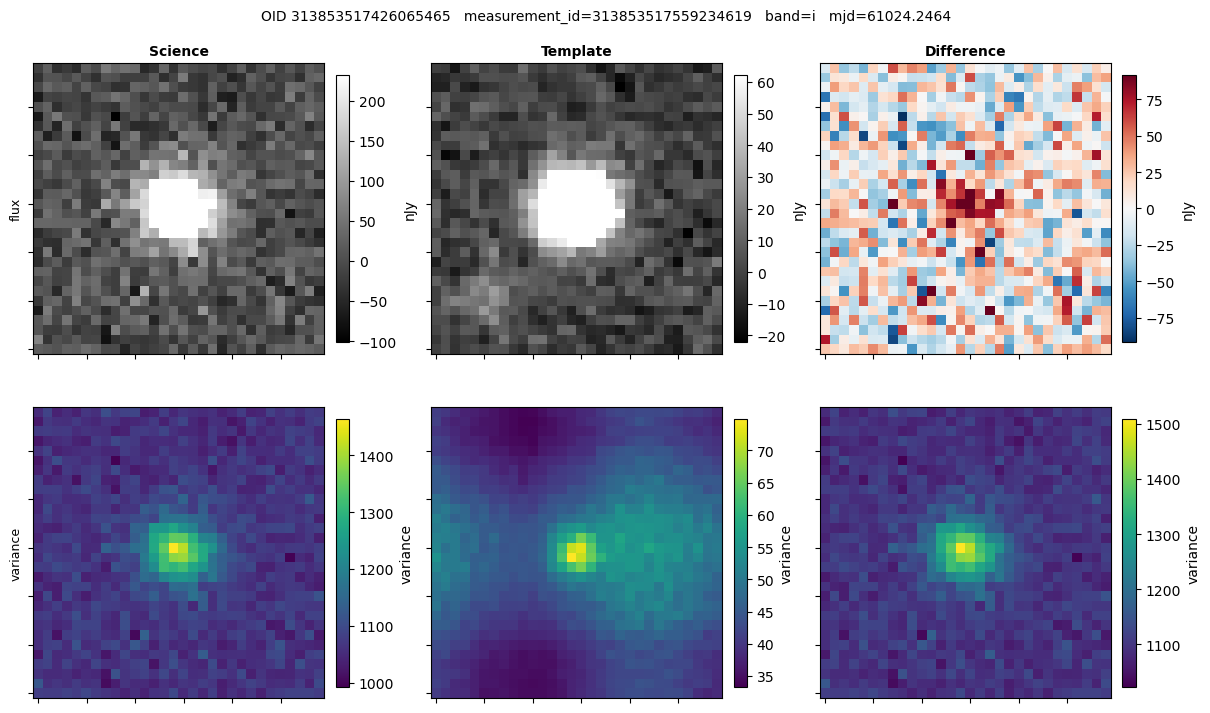

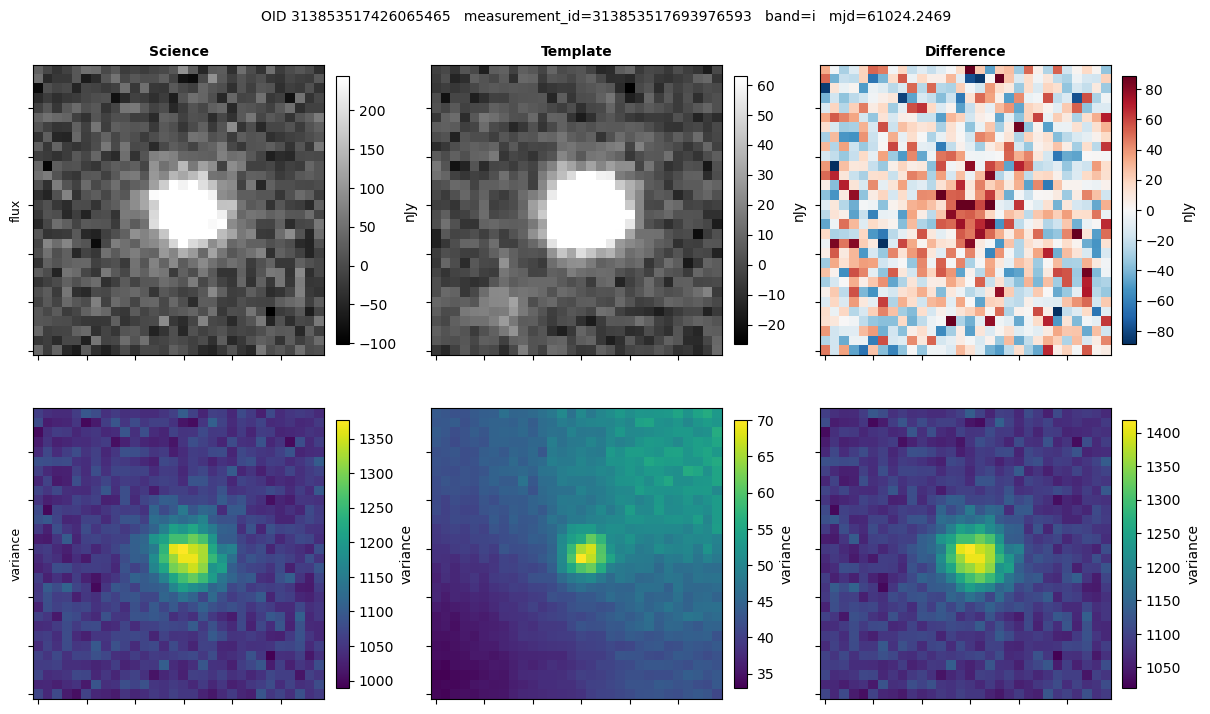

In [10]:
PLANES_TO_PLOT = PLANES[:1]   # flux only

CMAPS = {
    ("Science",    "flux"):     "gray",
    ("Template",   "flux"):     "gray",
    ("Difference", "flux"):     "RdBu_r",
    ("Science",    "variance"): "viridis",
    ("Template",   "variance"): "viridis",
    ("Difference", "variance"): "viridis",
}


def stretch(arr, stype, plane):
    arr = np.nan_to_num(arr)
    if plane == "flux" and stype == "Difference":
        absmax = np.nanpercentile(np.abs(arr), 99)
        return -absmax, absmax
    if plane == "flux":
        vmin, vmax = ZScaleInterval(contrast=0.25).get_limits(arr)
        return vmin, vmax
    return float(arr.min()), float(arr.max())


for entry in stamp_rows:
    mid   = entry["measurement_id"]
    ncols = len(STAMP_TYPES)
    nrows = len(PLANES_TO_PLOT)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3.6 * nrows),
        constrained_layout=True,
    )
    # Normalise axes to always be 2-D array
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for r, plane in enumerate(PLANES_TO_PLOT):
        for c, stype in enumerate(STAMP_TYPES):
            ax  = axes[r][c]
            hdu = entry.get(f"{stype}_{plane}")

            if hdu is None or hdu.data is None:
                ax.set_visible(False)
                continue

            arr = np.array(hdu.data, dtype=float)
            vmin, vmax = stretch(arr, stype, plane)
            cmap = CMAPS.get((stype, plane), "gray")

            im = ax.imshow(arr, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                         label="nJy" if plane == "flux" else plane)

            if r == 0:
                ax.set_title(stype, fontsize=10, fontweight="bold")
            if c == 0:
                ax.set_ylabel(plane, fontsize=9)
            ax.tick_params(labelbottom=False, labelleft=False)

    fig.suptitle(
        f"OID {OID}   measurement_id={mid}   band={entry['band']}   mjd={entry['mjd']:.4f}",
        fontsize=10,
    )
    plt.show()

## 11. List all files written to OID directory

In [11]:
all_files = sorted(OID_DIR.iterdir())
print(f"{len(all_files)} files in {OID_DIR}:\n")
for f in all_files:
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} kB)")

10 files in ../../data/313853517426065465:

  313853517426065465_313853517426065465_difference.fits  (33.8 kB)
  313853517426065465_313853517426065465_science.fits  (33.8 kB)
  313853517426065465_313853517426065465_template.fits  (36.6 kB)
  313853517426065465_313853517559234619_difference.fits  (33.8 kB)
  313853517426065465_313853517559234619_science.fits  (33.8 kB)
  313853517426065465_313853517559234619_template.fits  (33.8 kB)
  313853517426065465_313853517693976593_difference.fits  (33.8 kB)
  313853517426065465_313853517693976593_science.fits  (33.8 kB)
  313853517426065465_313853517693976593_template.fits  (33.8 kB)
  313853517426065465_detections.parquet  (426.3 kB)
